In [ ]:
!pip install -U \
langchain \
langchain-core \
langchain-community \
langchain-groq \
langchain-huggingface \
langgraph \
faiss-cpu \
pypdf \
python-dotenv \
tavily-python \
sentence-transformers

In [ ]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel
import re
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

False

In [ ]:
# -----------------------------
# Data + Index
# -----------------------------
docs = (
    PyPDFLoader("/content/book1.pdf").load()
    + PyPDFLoader("/content/book2.pdf").load()
    + PyPDFLoader("/content/book3.pdf").load()
)

In [ ]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")


In [ ]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [ ]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [ ]:
# -----------------------------
# State
# -----------------------------
class State(TypedDict):
    question: str

    docs: List[Document]
    good_docs: List[Document]

    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_query: str

    web_docs: List[Document]

    answer: str

In [ ]:
# -----------------------------
# Retrieve
# -----------------------------
def retrieve_node(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}


In [ ]:
# -----------------------------
# Score-based doc evaluator
# -----------------------------
class DocEvalScore(BaseModel):
    score: float
    reason: str


doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)


def eval_each_doc_node(state: State) -> State:
    q = state["question"]
    scores: List[float] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)

        # Keep any doc above LOWER_TH as "weakly relevant"
        if out.score > LOWER_TH:
            good.append(d)

    # CORRECT: at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # INCORRECT: all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}.",
        }

    # AMBIGUOUS: otherwise
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}.",
    }


In [ ]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool


filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence.\n"
            "Output JSON only. The value of 'keep' MUST be a boolean (true or false), not a string.",  # 👈 added
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


# -----------------------------
# Knowledge refinement
# (CORRECT => internal only)
# (INCORRECT => web only)
# (AMBIGUOUS => internal + web)
# -----------------------------
def refine(state: State) -> State:
    q = state["question"]

    if state.get("verdict") == "CORRECT":
        docs_to_use = state["good_docs"]
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state["web_docs"]
    else:  # AMBIGUOUS
        docs_to_use = state["good_docs"] + state["web_docs"]

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


In [ ]:
# -----------------------------
# Query rewrite for web search
# -----------------------------
class WebQuery(BaseModel):
    query: str


rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)


def rewrite_query_node(state: State) -> State:
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}


# -----------------------------
# Web search node: uses web_query
# -----------------------------
tavily = TavilySearchResults(max_results=5)


def web_search_node(state: State) -> State:
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    web_docs: List[Document] = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}


In [ ]:
# -----------------------------
# Generate
# -----------------------------
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)


def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "context": state["refined_context"]})
    return {"answer": out.content}


In [ ]:
# -----------------------------
# Routing
# CORRECT => refine
# INCORRECT / AMBIGUOUS => rewrite -> web_search -> refine -> generate
# -----------------------------
def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    else:
        return "rewrite_query"


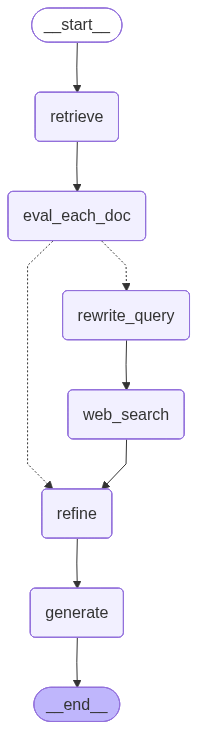

In [ ]:
# -----------------------------
# Build graph
# -----------------------------
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",
    },
)

# non-correct path
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")

# correct path already goes to refine
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app


In [ ]:
# -----------------------------
# Run example
# -----------------------------
res = app.invoke(
    {
        "question": "Batch normalization vs layer normalization",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_query": "",
        "web_docs": [],
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("WEB_QUERY:", res["web_query"])
print("\nOUTPUT:\n", res["answer"])


VERDICT: AMBIGUOUS
REASON: No chunk scored > 0.7, but not all were < 0.3.
WEB_QUERY: batch normalization vs layer normalization

OUTPUT:
 Batch normalization and layer normalization are two techniques used to normalize the inputs of a neural network. 

Batch normalization calculates the mean and standard deviation of each feature across the mini-batch, and then normalizes each instance using these feature-wise statistics. It is typically used for feedforward neural networks and convolutional neural networks.

Layer normalization, on the other hand, calculates the mean and standard deviation of each instance across all features, and then normalizes each feature using these instance-wise statistics. It is particularly useful for sequence models, such as recurrent neural networks (RNNs), and models with long-range dependencies, like transformers.

The key differences between batch normalization and layer normalization are:

1. **Calculation of statistics**: Batch normalization calculates 